# Lesson 4: Two Independent Groups

**Course:** hypothesis_testing_and_statistical_inference  
**Prerequisites:** Basic Python and descriptive statistics

This lesson follows a repeatable workflow: define the question, encode the design,
check assumptions, estimate the effect, quantify uncertainty, test the claim, and
communicate both statistical and practical meaning.


## Learning objectives

1. Use Welch's t-test as a robust default for independent means
2. Compute a confidence interval for the mean difference and Hedges' g
3. Use Mann–Whitney U for ordinal or rank-focused questions
4. Explain why test choice depends on the estimand, not only a normality p-value


## Setup

Run this cell first. Every example uses a fixed random seed so results are reproducible.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Work whether the kernel starts in the course root or a level folder.
working_dir = Path.cwd()
COURSE_ROOT = working_dir if (working_dir / "data").exists() else working_dir.parent
DATA_DIR = COURSE_ROOT / "data"

rng = np.random.default_rng(20260920)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.precision", 4)


## 4.1 Design and estimand

Two independent groups contain different observational units. Welch's t-test targets a difference in
population means without assuming equal variances. It is generally a safer default than the pooled
equal-variance t-test.

Mann–Whitney U tests a rank/distributional contrast. Interpreting it as a median test requires similar
distribution shapes; it is not automatically a drop-in test of means.


In [2]:
anes = pd.read_csv(DATA_DIR / "anes96_clean.csv")
clinton = anes.loc[anes["expected_vote"] == "Clinton", "age_years"].to_numpy()
dole = anes.loc[anes["expected_vote"] == "Dole", "age_years"].to_numpy()

welch = stats.ttest_ind(dole, clinton, equal_var=False)
n1, n2 = len(dole), len(clinton)
m1, m2 = dole.mean(), clinton.mean()
v1, v2 = dole.var(ddof=1), clinton.var(ddof=1)
se = np.sqrt(v1/n1 + v2/n2)
df = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
diff = m1-m2
ci = diff + np.array([-1, 1])*stats.t.ppf(.975, df)*se
pooled_sd = np.sqrt(((n1-1)*v1+(n2-1)*v2)/(n1+n2-2))
d = diff/pooled_sd
hedges_g = (1-3/(4*(n1+n2)-9))*d

pd.Series({"Dole mean age": m1, "Clinton mean age": m2, "difference": diff,
           "95% CI low": ci[0], "95% CI high": ci[1], "Welch t": welch.statistic,
           "df": df, "p": welch.pvalue, "Hedges g": hedges_g})


Dole mean age        48.0865
Clinton mean age     46.2995
difference            1.7871
95% CI low           -0.3400
95% CI high           3.9141
Welch t               1.6491
df                  843.5343
p                     0.0995
Hedges g              0.1088
dtype: float64

/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


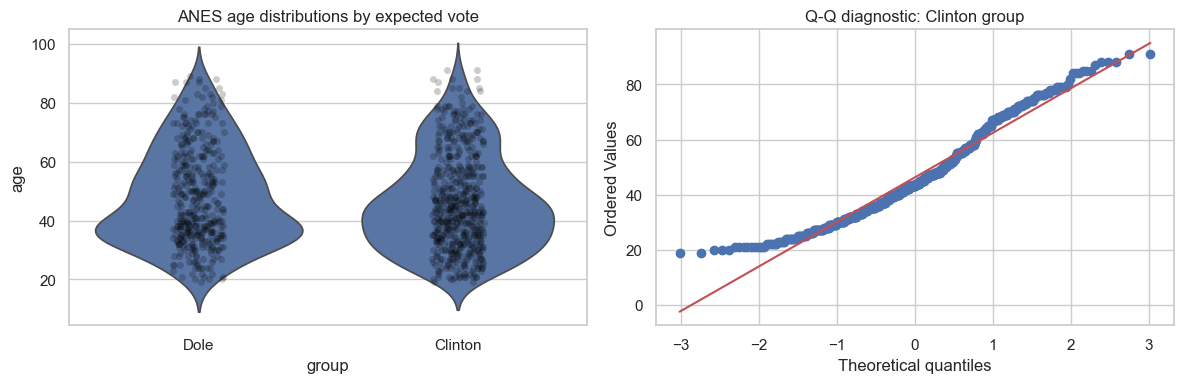

In [3]:
tidy = anes[["age_years", "expected_vote"]].rename(
    columns={"age_years": "age", "expected_vote": "group"})
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.violinplot(data=tidy, x="group", y="age", inner=None, ax=axes[0])
sns.stripplot(data=tidy, x="group", y="age", color="black", alpha=.2, ax=axes[0])
axes[0].set_title("ANES age distributions by expected vote")
stats.probplot(clinton, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q diagnostic: Clinton group")
plt.tight_layout(); plt.show()


In [4]:
mw = stats.mannwhitneyu(dole, clinton, alternative="two-sided")
rank_biserial = 2*mw.statistic/(n1*n2)-1
pd.Series({"U": mw.statistic, "p": mw.pvalue,
           "rank-biserial correlation (Dole-Clinton)": rank_biserial,
           "Dole median age": np.median(dole),
           "Clinton median age": np.median(clinton)})


U                                           114961.5000
p                                                0.1052
rank-biserial correlation (Dole-Clinton)         0.0618
Dole median age                                 45.0000
Clinton median age                              43.0000
dtype: float64

## Worked example and interpretation

### How the groups are compared

The ANES example defines two non-overlapping respondent groups by expected vote and measures age, with every respondent counted once. Welch's test estimates the **Dole minus Clinton** mean-age difference without requiring equal group variances. The sample means are 48.09 and 46.30 years, respectively, giving a difference of 1.79 years. Its 95% interval runs from −0.34 to 3.91 years and the p-value is 0.0995; Hedges' g is 0.109. The interval includes zero and effects in both directions, so the data do not pin down a reliable mean difference at the 0.05 threshold. The violin/point display and Q–Q diagnostic help inspect distribution shape and outliers.

### Why the rank analysis is separate

The notebook also calculates Mann–Whitney U, with p = 0.105 and rank-biserial correlation 0.062. The group medians are 45 and 43 years. This method compares relative ordering of observations; it is not automatically a test of median equality when distribution shapes differ. Both analyses are observational comparisons. Expected-vote groups were not randomized, so even a clear age difference would not show that vote preference caused age to change.

## Practice and solution

**Practice.** Why is selecting Welch versus Mann–Whitney solely from a Shapiro–Wilk p-value weak?

<details><summary>Solution</summary>

The tests target different quantities. Normality tests have low power in small samples and excessive
sensitivity in large samples. Use the scientific estimand, design, plots, outlier influence, and sample
size. Welch's test is often robust for means; Mann–Whitney is natural for ordinal outcomes or a
probability-of-superiority/rank contrast.
</details>

## Key takeaways

- Verify independence from the design.
- Prefer Welch for an independent mean difference unless equal-variance pooling is justified.
- Report the raw-unit difference and CI alongside a standardized effect.


## Reproducibility checklist

- State the population, outcome, groups, and sampling unit.
- State $H_0$, $H_1$, alpha, and whether the test is one- or two-sided before looking at results.
- Verify independence from the design; use plots and diagnostics for distributional assumptions.
- Report the estimate, confidence interval, effect size, test statistic, degrees of freedom, and exact p-value.
- Separate statistical evidence from practical importance and acknowledge design limitations.
